<a href="https://colab.research.google.com/github/Vedant28082005/CV-2026-H10/blob/main/LAB5/CV_LAB_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

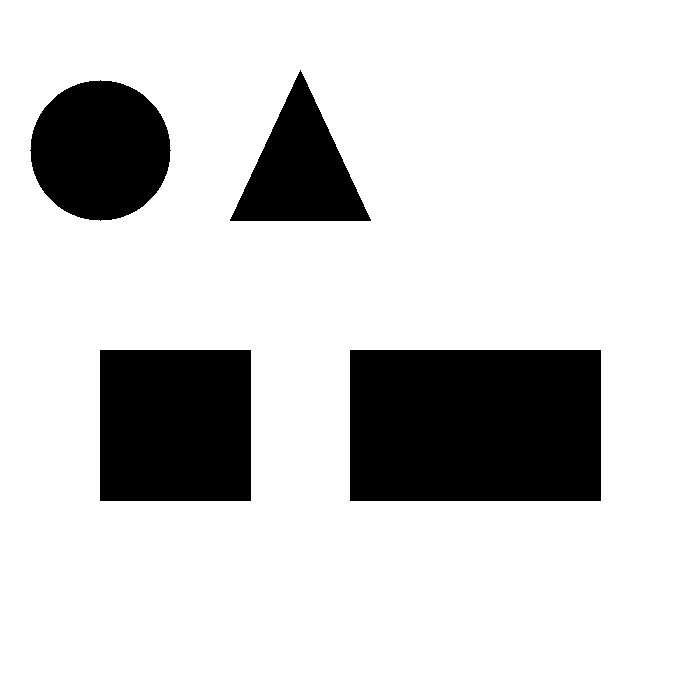

In [69]:
image = cv2.imread("/content/shapes.png" , cv2.IMREAD_GRAYSCALE)
cv2_imshow(image)

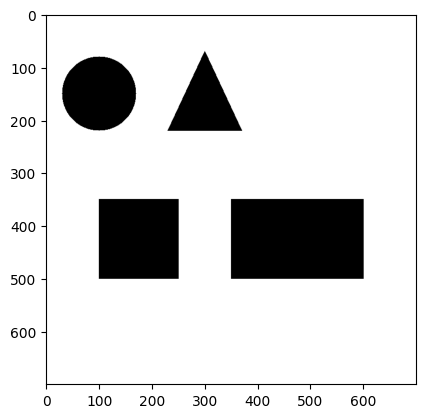

In [70]:
plt.imshow(image, cmap='gray')

In [71]:
kernel_size = 3
k = kernel_size // 2

y_d = ([-1 ,-2 , -1] , [0,0,0] , [1 , 2 , 1])
x_d = np.transpose(y_d)

In [72]:
padded = np.pad( image, ((k, k), (k, k)), mode='edge')
out_h, out_w = image.shape
detect_x = np.zeros((out_h, out_w), dtype=np.uint8)
detect_y = np.zeros((out_h, out_w), dtype=np.uint8)

for i in range(out_h):
        for j in range(out_w):
            region = padded[i:i + kernel_size, j:j + kernel_size]
            detect_x[i, j] = np.sum(region * x_d)
            detect_y[i, j] = np.sum(region * y_d)

detect_x = np.clip(detect_x, 0, 255).astype(np.uint8)
detect_y = np.clip(detect_y, 0, 255).astype(np.uint8)

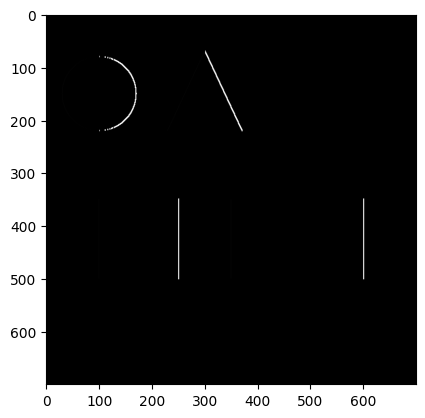

In [73]:
plt.imshow(detect_x, cmap='gray')

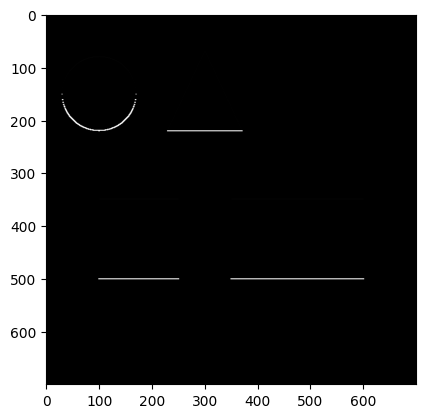

In [74]:
plt.imshow(detect_y, cmap='gray')

In [75]:
resultant = np.zeros(image.shape)

for i in range(out_h):
    for j in range(out_w):
        resultant[i, j] = np.sqrt(detect_x[i, j] ** 2 + detect_y[i, j] ** 2)

#resultant = np.clip(resultant, 0, 255).astype(np.uint8)

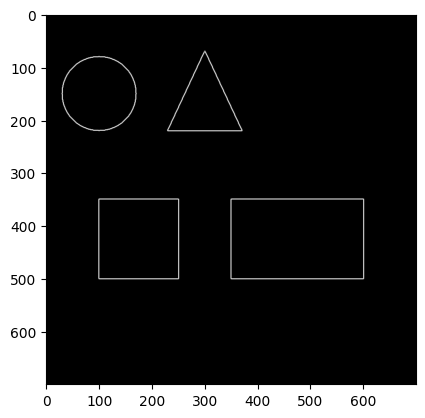

In [76]:
plt.imshow(resultant, cmap='gray')